Likelihood Function: Start Here
===============================

This script gives a step-by-step walkthrough of the IC50 likelihood used
throughout `ic50_workspace`. It complements `scripts/simulator.py`: where
the simulator generates data from a known truth, this tutorial shows how
the likelihood function scores a given set of Hill parameters against
that data.

By the end of the script the reader has seen:

- The Hill curve evaluated at the true parameters of one simulated dataset,
  plotted against the data, with the chi² and log-likelihood printed.
- The same evaluation at deliberately wrong parameters — the chi² goes up
  and the log-likelihood goes down, exactly as it should.
- The global linear-model likelihood used for sample-wide fits, where
  `pred_hill_params = latent_array @ coef_matrix + coef_mean` predicts
  every cell line's Hill parameters from a shared global model.
- A sanity check on one real GDSC2 dataset, plotted with a hand-tuned
  Hill fit, confirming the same code path runs on real data.

All Hill curve and plotting helpers come from `scripts/util.py`. The
likelihood math is written inline here so the reader can read it directly,
but it is the same expression used by `util.log_likelihood` and the wider
fitting code.

__Contents__

- **Load Simulated Dataset:** Read one simulated cell-line and its ground
  truth.
- **Single-Dataset Hill Likelihood at the True Parameters:** Evaluate the
  Hill curve at the truth, plot it, print chi² and log-likelihood.
- **Wrong Parameters:** Repeat the calculation at three deliberately wrong
  parameter sets and confirm the truth wins.
- **Global Linear-Model Likelihood:** Sample-wide log-likelihood summed
  over all simulated cell lines, scored using the global linear map
  `coef_matrix @ latent + coef_mean`.
- **Real Data Sanity Check:** Evaluate the same likelihood on a real
  GDSC2 cell line with a hand-tuned Hill fit.
- **Wrap Up:** Pointers to the next scripts.

In [1]:

import json
import sys
from pathlib import Path

import numpy as np

Make `util.py` importable whether this script is run directly or executed
inside a Jupyter notebook generated from it (the same shim used by
`simulator.py`).

In [2]:
try:
    here = Path(__file__).resolve().parent
except NameError:  # running inside Jupyter where __file__ is undefined
    here = Path.cwd()
sys.path.insert(0, str(here))

from util import hill_curve, plot_dataset

workspace_root = here.parent
sim_path = workspace_root / "dataset" / "ic50_sim"
real_path = workspace_root / "dataset" / "cancer_real__drug_1073"
plot_dir = sim_path / "likelihood_function"
plot_dir.mkdir(parents=True, exist_ok=True)

__Load Simulated Dataset__

Load one simulated cell-line (`dataset_0`) along with its ground-truth Hill
parameters. The simulator wrote `true_params.json` for exactly this purpose:
to let downstream scripts evaluate the likelihood at known truth and check
the answer.

In [3]:
ds_path = sim_path / "dataset_0"
x = np.load(ds_path / "x.npy")
y = np.load(ds_path / "y.npy")
info = json.load(open(ds_path / "info.json"))
truth = json.load(open(ds_path / "true_params.json"))

sigma = info["noise_sigma"]
true_log_ic50 = truth["log_ic50"]
true_n_log = truth["n_log"]
true_base = truth["base"]

print(f"Loaded dataset_0  (n_doses={len(x)},  noise_sigma={sigma:.0f})")
print(f"  x = {np.round(x, 3)}")
print(f"  y = {np.round(y, 0)}")
print(
    f"  truth: log_ic50={true_log_ic50:.3f},  "
    f"n={np.exp(true_n_log):.3f},  base={true_base:.0f}"
)

Loaded dataset_0  (n_doses=7,  noise_sigma=9099)
  x = [0.    0.693 1.099 1.386 1.609 1.792 1.946]
  y = [28630. 20605.  5990. 11830.  9169.  8922. 13970.]
  truth: log_ic50=0.588,  n=1.109,  base=33258


__Single-Dataset Hill Likelihood at the True Parameters__

The Hill curve evaluated at the true parameters should sit cleanly through
the data points (within the σ errorbars). The Gaussian log-likelihood for
this dataset is

    log L = -0.5 * sum( ((y_pred - y) / sigma) ** 2 )

We write the Hill function inline below so the math is on the page rather
than hidden inside `util.hill_curve`. This is the same expression that
`util.hill_curve` runs internally — sign convention `n*(x - log_ic50)`
giving the canonical decreasing dose-response.


Hill at the TRUE parameters:
  chi^2          = 2.165
  log-likelihood = -1.083


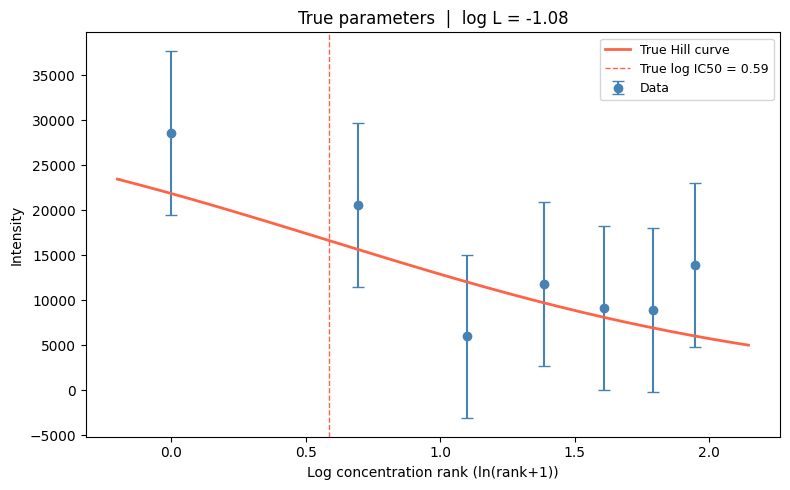

In [4]:
n_true = np.exp(true_n_log)
nkx = np.clip(n_true * (x - true_log_ic50), -500, 500)
y_pred_true = true_base / (1.0 + np.exp(nkx))

chi_squared_true = float(np.sum(((y - y_pred_true) / sigma) ** 2))
log_likelihood_true = -0.5 * chi_squared_true

print()
print("Hill at the TRUE parameters:")
print(f"  chi^2          = {chi_squared_true:.3f}")
print(f"  log-likelihood = {log_likelihood_true:.3f}")

plot_dataset(
    x,
    y,
    sigma,
    title=f"True parameters  |  log L = {log_likelihood_true:.2f}",
    true_params={
        "log_ic50": true_log_ic50,
        "n_log": true_n_log,
        "base": true_base,
    },
    output_path=plot_dir / "true_fit.png",
)

__Wrong Parameters__

Now evaluate the same likelihood at three deliberately wrong parameter
sets. Each one shifts a single Hill parameter so the curve visibly fails
to match the data: the IC50 moves away from the inflection point, the
plateau shrinks, or the slope becomes too sharp. The chi² should grow and
the log-likelihood should drop in every case.

For each wrong fit we plot the curve over the data via
`util.plot_dataset(..., fit_params=...)` (crimson overlay) so the reader
can see the curve diverging from the points.


  parameters                  chi^2        log L      Δ log L
  ------------------------------------------------------------
  truth                        2.17        -1.08         0.00
  log_ic50 + 1.0               4.48        -2.24        -1.16


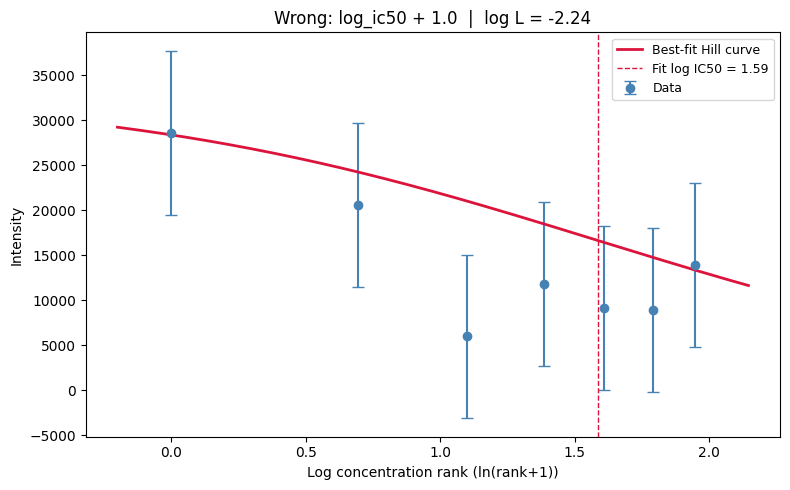

  base * 0.5                   8.46        -4.23        -3.15


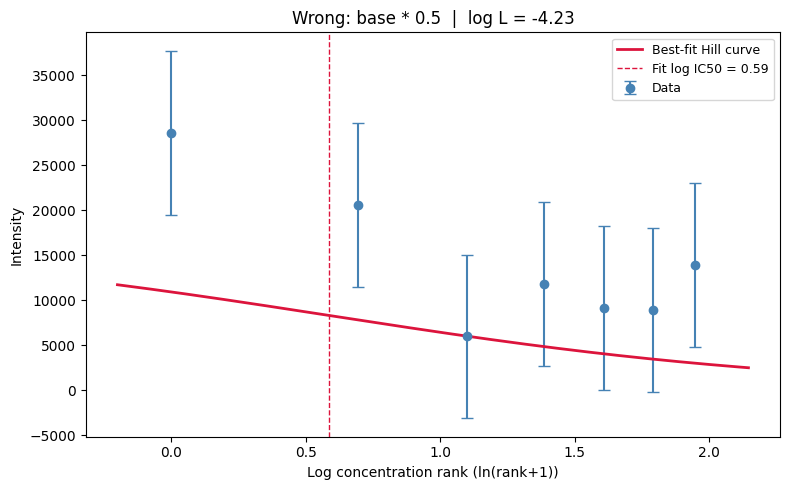

  n_log + 1.5                  6.85        -3.42        -2.34


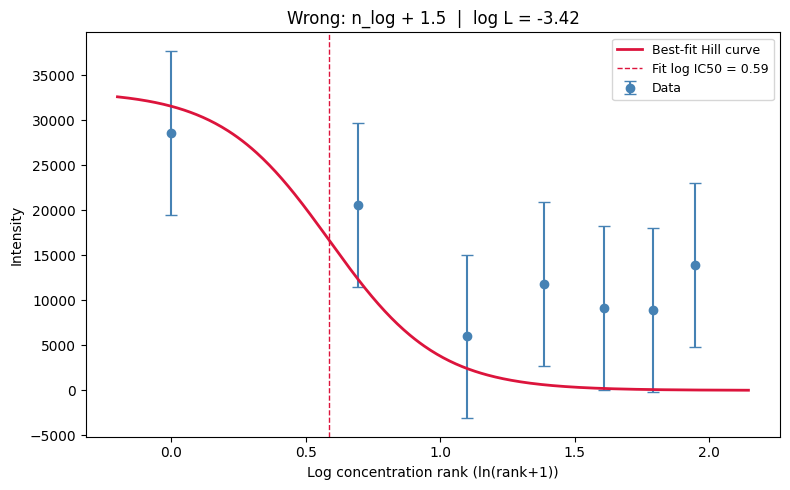

In [5]:


def chi_sq_and_log_L(x, y, sigma, log_ic50, n_log, base):
    """Single-dataset Hill chi² and Gaussian log-likelihood (inline)."""
    n = np.exp(n_log)
    nkx = np.clip(n * (x - log_ic50), -500, 500)
    y_pred = base / (1.0 + np.exp(nkx))
    chi2 = float(np.sum(((y - y_pred) / sigma) ** 2))
    return chi2, -0.5 * chi2


wrong_params_list = [
    ("log_ic50 + 1.0", true_log_ic50 + 1.0, true_n_log, true_base),
    ("base * 0.5", true_log_ic50, true_n_log, 0.5 * true_base),
    ("n_log + 1.5", true_log_ic50, true_n_log + 1.5, true_base),
]

print()
print(f"  {'parameters':<20} {'chi^2':>12} {'log L':>12} {'Δ log L':>12}")
print(f"  {'-' * 60}")
print(
    f"  {'truth':<20} {chi_squared_true:>12.2f} "
    f"{log_likelihood_true:>12.2f} {0.0:>12.2f}"
)
for label, log_ic50_w, n_log_w, base_w in wrong_params_list:
    chi2_w, log_L_w = chi_sq_and_log_L(x, y, sigma, log_ic50_w, n_log_w, base_w)
    print(
        f"  {label:<20} {chi2_w:>12.2f} {log_L_w:>12.2f} "
        f"{(log_L_w - log_likelihood_true):>12.2f}"
    )
    assert log_L_w < log_likelihood_true, "wrong params should not beat truth"

    safe_label = label.replace(" ", "_").replace("*", "x").replace("+", "plus")
    plot_dataset(
        x,
        y,
        sigma,
        title=f"Wrong: {label}  |  log L = {log_L_w:.2f}",
        fit_params={"log_ic50": log_ic50_w, "n_log": n_log_w, "base": base_w},
        output_path=plot_dir / f"wrong_{safe_label}.png",
    )

__Global Linear-Model Likelihood__

For sample-wide fits we predict every cell line's three Hill parameters
from its latent gene-expression vector via a shared linear map:

    pred_hill_params[i] = latent_array[i] @ coef_matrix + coef_mean

with `coef_matrix` of shape `(n_latent, 3)` and `coef_mean` of shape `(3,)`.
The simulator wrote the true `coef_matrix`, `coef_mean`, `latent_array`,
and `hill_params_true` into `_sample/`, so we can verify that the
prediction step is exact at truth and then sum the per-dataset Hill
log-likelihoods to get the global log-likelihood.

In [6]:
sample = sim_path / "_sample"
coef_matrix_true = np.load(sample / "coef_matrix_true.npy")
coef_mean_true = np.load(sample / "coef_mean_true.npy")
latent_array = np.load(sample / "latent_array.npy")
hill_params_true = np.load(sample / "hill_params_true.npy")

pred_hill_params = latent_array @ coef_matrix_true + coef_mean_true
assert np.allclose(pred_hill_params, hill_params_true), (
    "global linear map should reproduce hill_params_true exactly at truth"
)

n_datasets = len(latent_array)


def global_log_likelihood(pred_hill_params):
    """Sum the per-dataset Hill log-likelihoods over all simulated cell lines."""
    total = 0.0
    for i in range(n_datasets):
        x_i = np.load(sim_path / f"dataset_{i}" / "x.npy")
        y_i = np.load(sim_path / f"dataset_{i}" / "y.npy")
        info_i = json.load(open(sim_path / f"dataset_{i}" / "info.json"))
        _, log_L_i = chi_sq_and_log_L(
            x_i, y_i, info_i["noise_sigma"], *pred_hill_params[i]
        )
        total += log_L_i
    return total


log_L_global_true = global_log_likelihood(pred_hill_params)
print()
print("Global linear-model log-likelihood:")
print(f"  truth coef_matrix     -> log L = {log_L_global_true:.3f}")


Global linear-model log-likelihood:
  truth coef_matrix     -> log L = -9.799


Now perturb the global `coef_matrix` and re-derive the per-dataset Hill
predictions. With the global map shifted, the predicted Hill parameters no
longer match the data and the global log-likelihood falls.

In [7]:
coef_matrix_perturbed = coef_matrix_true.copy()
coef_matrix_perturbed[:, 0] += 0.5  # shift the log_ic50 coefficient column
pred_hill_perturbed = latent_array @ coef_matrix_perturbed + coef_mean_true
log_L_global_wrong = global_log_likelihood(pred_hill_perturbed)
print(f"  perturbed coef_matrix -> log L = {log_L_global_wrong:.3f}")
assert log_L_global_wrong < log_L_global_true, (
    "perturbed global map should give a lower global log-likelihood"
)

  perturbed coef_matrix -> log L = -12.656


__Real Data Sanity Check__

The same likelihood expression should be runnable on real GDSC2 data. Here
we load `dataset_20`, the cell line we previewed in `simulator.py`, and
evaluate the Hill log-likelihood at a hand-tuned Hill fit chosen by eye:

  - `log_ic50 ≈ 1.5`  (curve drops near the upper end of the dose range)
  - `n_log = 0.0`     (n = 1, a moderate slope)
  - `base ≈ y[0]`     (top plateau matches the lowest-dose intensity)

A real fit (e.g. via AutoFit) would replace these hand-tuned values with
the posterior median, but for a sanity check this is enough to confirm
the likelihood is finite and the plotting works on real data.


Real GDSC2 drug-1073 dataset_20 with hand-tuned Hill fit:
  log_ic50=1.5,  n=1.0,  base=63176
  chi^2          = 18.712
  log-likelihood = -9.356


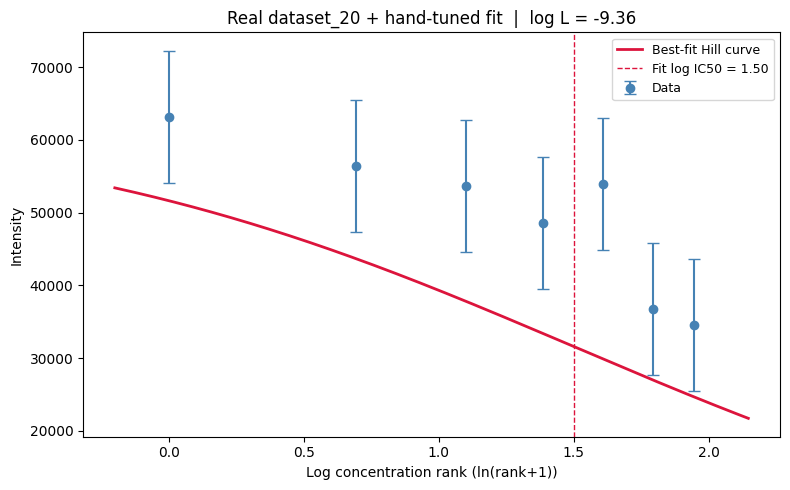

In [8]:
real_ds = real_path / "dataset_20"
x_real = np.load(real_ds / "x.npy")
y_real = np.load(real_ds / "y.npy")
info_real = json.load(open(real_ds / "info.json"))

hand_tuned = {"log_ic50": 1.5, "n_log": 0.0, "base": float(y_real[0])}
chi2_real, log_L_real = chi_sq_and_log_L(
    x_real,
    y_real,
    info_real["noise_sigma"],
    hand_tuned["log_ic50"],
    hand_tuned["n_log"],
    hand_tuned["base"],
)

print()
print("Real GDSC2 drug-1073 dataset_20 with hand-tuned Hill fit:")
print(
    f"  log_ic50={hand_tuned['log_ic50']},  "
    f"n=1.0,  base={hand_tuned['base']:.0f}"
)
print(f"  chi^2          = {chi2_real:.3f}")
print(f"  log-likelihood = {log_L_real:.3f}")

plot_dataset(
    x_real,
    y_real,
    info_real["noise_sigma"],
    title=f"Real dataset_20 + hand-tuned fit  |  log L = {log_L_real:.2f}",
    fit_params=hand_tuned,
    output_path=plot_dir / "real_fit.png",
)

__Wrap Up__

`util.py` owns the canonical Hill curve and the canonical Gaussian log-
likelihood; the inline expressions above are the same formula made
readable. Everywhere downstream — `one_by_one.py`, `ep.py`, `graphical.py`
and friends — should call `util.hill_curve` rather than re-implementing
this loop.

Next steps for the curious reader:

  - `scripts/one_by_one.py` (forthcoming) wraps this likelihood inside an
    AutoFit `Analysis` class and runs a non-linear search on a single
    dataset.
  - `scripts/ep.py` (forthcoming) will fit the global linear model used
    above with expectation propagation across all simulated cell lines.

All plots from this script are saved under
`dataset/ic50_sim/likelihood_function/`.

In [9]:
print()
print(f"Plots saved in {plot_dir}/")



Plots saved in /home/jammy/Code/PyAutoLabs/z_projects/ic50_workspace/dataset/ic50_sim/likelihood_function/
